<a href="https://colab.research.google.com/github/punypeony/CCOBJPGL_EXERCISES_COM246-1/blob/main/Santiago_Exercise1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 1

Create a model using K-Nearest Neigbors to perform classification using the personality dataset.

0 -'introvert'

1 - 'extrovert'

## A. Import libraries

In [ ]:
import sklearn
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/exercise_1/personality_dataset.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


ModuleNotFoundError: No module named 'Numpy'

In [ ]:
import os

# List the contents of the directory where the file is expected to be
drive_path = '/content/drive/MyDrive/exercise1/'

if os.path.exists(drive_path):
    print(f"Contents of {drive_path}:")
    for item in os.listdir(drive_path):
        print(item)
else:
    print(f"The directory '{drive_path}' does not exist. Please check your Google Drive path.")

The directory '/content/drive/MyDrive/exercise1/' does not exist. Please check your Google Drive path.


## B. Load and understand the dataset

Display the first 5 rows of the dataset using `.head()`

In [ ]:
print(df.head())

   Time_spent_Alone Stage_fear  Social_event_attendance  Going_outside  \
0                 3        Yes                        6              7   
1                 2         No                        8              6   
2                 1         No                        9              4   
3                 8         No                        0              0   
4                 5        Yes                        3              0   

  Drained_after_socializing  Friends_circle_size  Post_frequency Personality  
0                        No                   14               5   Extrovert  
1                        No                    7               8   Extrovert  
2                        No                    9               3   Extrovert  
3                       Yes                    9               3   Introvert  
4                        No                    2               6   Introvert  


Display the summary of all the features of the dataset using `.info()`

In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Time_spent_Alone           5000 non-null   int64 
 1   Stage_fear                 5000 non-null   object
 2   Social_event_attendance    5000 non-null   int64 
 3   Going_outside              5000 non-null   int64 
 4   Drained_after_socializing  5000 non-null   object
 5   Friends_circle_size        5000 non-null   int64 
 6   Post_frequency             5000 non-null   int64 
 7   Personality                5000 non-null   object
dtypes: int64(5), object(3)
memory usage: 312.6+ KB
None


Display the total number of samples from each label using `.value_counts()`

In [ ]:
print(df['Personality'].value_counts())

Personality
Introvert    2502
Extrovert    2498
Name: count, dtype: int64


Use a histogram to display the number of followers for each samples
 - The x axis should be the number of followers/friends
 - The y axis should be the number of samples in the dataset

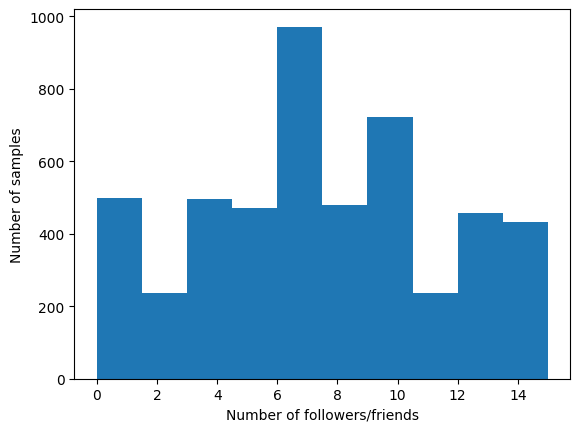

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('/content/drive/MyDrive/exercise_1/personality_dataset.csv')
plt.hist(df["Friends_circle_size"])

plt.xlabel("Number of followers/friends")
plt.ylabel("Number of samples")

plt.show()

Remove the name column using `drop()` method

In [ ]:
# The 'Name' column was not found in the DataFrame. It seems it does not exist in this dataset, so no action is needed here.

KeyError: "['Name'] not found in axis"

## C. Split the dataset into training and test set

Convert the features into an numpy array using `.values()` and store it in a variable "X"

In [ ]:
features = [
    "Time_spent_Alone",
    "Stage_fear",
    "Social_event_attendance",
    "Going_outside",
    "Drained_after_socializing",
    "Friends_circle_size",
    "Post_frequency"
]

# Identify categorical columns that need one-hot encoding
categorical_features = ['Stage_fear', 'Drained_after_socializing']

# Create a temporary DataFrame with only the selected features for encoding
df_temp = df[features].copy()

# Apply one-hot encoding to the categorical features
# drop_first=True is used to avoid multicollinearity by dropping the first category of each feature
df_encoded = pd.get_dummies(df_temp, columns=categorical_features, drop_first=True)

# Convert the processed DataFrame to a NumPy array
x = df_encoded.to_numpy()

print(x)

[[3 6 7 ... 5 True False]
 [2 8 6 ... 8 False False]
 [1 9 4 ... 3 False False]
 ...
 [2 7 3 ... 3 False False]
 [2 9 3 ... 7 True False]
 [4 6 7 ... 3 True False]]


Convert the labels into an numpy array using `.values()` and store it in a variable "y"

In [ ]:
features = [
    "Time_spent_Alone",
    "Stage_fear",
    "Social_event_attendance",
    "Going_outside",
    "Drained_after_socializing",
    "Friends_circle_size",
    "Post_frequency"
]

y = df['Personality'].to_numpy()

print(y)
print(y.shape)

['Extrovert' 'Extrovert' 'Extrovert' ... 'Extrovert' 'Extrovert'
 'Extrovert']
(5000,)


Use `train_test_split()` to split the data.

- Declare a variable `X_train` that will hold the training data
- Declare a variable `X_test` that will hold the test data
- Declare a variable `y_train` that will hold the label of the training data
- Declare a variable `y_test` that will hold the label of the test data


In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y)

Display the dimensions of each variables using `.shape()`

In [ ]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(3750, 7)
(1250, 7)
(3750,)
(1250,)


## D. Create the model

Use KNN as a classifier by using `KNeighborsClassifier()`

In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)

Train the model using the `.fit()`

In [ ]:
knn.fit(x_train, y_train)

KNeighborsClassifier()

Test the model using the `.predict()`

In [ ]:
y_pred = knn.predict(x_test)
print(y_pred)

['Introvert' 'Introvert' 'Extrovert' ... 'Introvert' 'Introvert'
 'Extrovert']


## E. Evaluate the model

Create a confusion matrix

In [ ]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[607   3]
 [  7 633]]


Display the accuracy

In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print(accuracy)

0.992


Display the precision

In [ ]:
precision = precision_score(y_test, y_pred, pos_label="Extrovert")

print("Precision:", precision)

Precision: 0.988599348534202


Display the recall

In [ ]:


print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

   Extrovert       0.99      1.00      0.99       610
   Introvert       1.00      0.99      0.99       640

    accuracy                           0.99      1250
   macro avg       0.99      0.99      0.99      1250
weighted avg       0.99      0.99      0.99      1250



Display the f1-score

In [ ]:


print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

   Extrovert       0.99      1.00      0.99       610
   Introvert       1.00      0.99      0.99       640

    accuracy                           0.99      1250
   macro avg       0.99      0.99      0.99      1250
weighted avg       0.99      0.99      0.99      1250



## F. Predict your own personality

Enter your own features and use the model to generate a prediction using `.predict()`

In [ ]:
# Get user input
time_alone = int(input("Time spent alone: "))
stage_fear = input("Stage fear (Yes/No): ")
social_event = int(input("Social event attendance: "))
going_outside = int(input("Going outside: "))
drained = input("Drained after socializing (Yes/No): ")
friends = int(input("Friends circle size: "))
posts = int(input("Post frequency: "))

# Convert Yes/No into numbers
stage_fear = 1 if stage_fear == "Yes" else 0
drained = 1 if drained == "Yes" else 0

# Create sample
user = pd.DataFrame({
    "Time_spent_Alone": [time_alone],
    "Stage_fear_Yes": [stage_fear],
    "Social_event_attendance": [social_event],
    "Going_outside": [going_outside],
    "Drained_after_socializing_Yes": [drained],
    "Friends_circle_size": [friends],
    "Post_frequency": [posts]
})

# Convert to numpy
user = user.to_numpy()

# Predict
prediction = knn.predict(user)

print("Predicted Personality:", prediction[0])

Time spent alone: 0
Stage fear (Yes/No): No
Social event attendance: 20
Going outside: 20
Drained after socializing (Yes/No): No
Friends circle size: 20
Post frequency: 20
Predicted Personality: Extrovert
